# LSTM Forecasting - Suzuki Collision Parts

D8 Solutions - Carlota

This notebook follows the same evaluation line as the XGBoost notebook:

- Use `sales_collision.csv` as the common input.
- Train one global LSTM per demand type: Smooth, Intermittent, Erratic and Lumpy.
- Compare the LSTM against a 3-month rolling-average baseline using WMAPE.
- Use a 3-month forecast lag to respect the operating cadence.
- Produce SKU-level forecasts for the next 18 months.

Important modelling note: LSTM models need fixed-length historical sequences. SKUs
with insufficient history are handled with a transparent rolling-average fallback.



In [27]:
# If running in Google Colab, upload sales_collision.csv to the session or mount Drive.
# from google.colab import drive
# drive.mount('/content/drive')

In [28]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
    from tensorflow.keras.losses import Huber
    from tensorflow.keras.optimizers import Adam
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required for this notebook. In Colab it is usually preinstalled. "
        "If needed, run: %pip install -q tensorflow"
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Load data

Change `DATA_PATH` if the file is stored in Google Drive.



In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Drive path:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Employers Project/Analysis/sales_collision.csv"

sales_collision = pd.read_csv(DATA_PATH)

required_cols = ["sku_id", "month", "demand", "demand_type"]
missing_cols = [c for c in required_cols if c not in sales_collision.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

sales_collision["month"] = pd.to_datetime(sales_collision["month"])
sales_collision["demand"] = pd.to_numeric(sales_collision["demand"], errors="coerce").fillna(0.0)
sales_collision = sales_collision.sort_values(["sku_id", "month"]).reset_index(drop=True)

print(f"Rows: {len(sales_collision):,}")
print(f"SKUs: {sales_collision['sku_id'].nunique():,}")
print(f"Period: {sales_collision['month'].min().date()} to {sales_collision['month'].max().date()}")
print("\nDemand types by SKU:")
print(sales_collision.groupby("sku_id")["demand_type"].first().value_counts())

Rows: 180,422
SKUs: 8,097
Period: 2024-01-01 to 2026-04-01

Demand types by SKU:
demand_type
Intermittent          6593
Smooth                 972
Lumpy                  381
Erratic                124
No demand observed      27
Name: count, dtype: int64


## 2. Add volume tiers

These flags mirror David's XGBoost notebook, so results can be compared using the
same top 20% and top 5% demand groups.



In [31]:
total_demand_by_sku = sales_collision.groupby("sku_id")["demand"].sum().rename("total_demand_sku")
sales_collision = sales_collision.merge(total_demand_by_sku, on="sku_id", how="left")

threshold_20 = sales_collision["total_demand_sku"].quantile(0.80)
threshold_5 = sales_collision["total_demand_sku"].quantile(0.95)

sales_collision["is_top20pct"] = (sales_collision["total_demand_sku"] >= threshold_20).astype(int)
sales_collision["is_top5pct"] = (sales_collision["total_demand_sku"] >= threshold_5).astype(int)

volume_summary = (
    sales_collision[["sku_id", "demand_type", "total_demand_sku", "is_top20pct", "is_top5pct"]]
    .drop_duplicates()
    .groupby(["demand_type", "is_top20pct"])
    .agg(n_skus=("sku_id", "count"), total_demand=("total_demand_sku", "sum"))
    .reset_index())
display(volume_summary)

,demand_type,is_top20pct,n_skus,total_demand
0,Erratic,0,7,188.0
1,Erratic,1,117,15861.0
2,Intermittent,0,6385,42836.0
3,Intermittent,1,208,9973.0
4,Lumpy,0,286,4469.0
5,Lumpy,1,95,7880.0
6,No demand observed,0,27,0.0
7,Smooth,0,67,628.0
8,Smooth,1,905,155689.0


## 3. Evaluation functions



In [32]:
FORECAST_LAG = 3
N_FORECAST = 18
WINDOW = 12
MIN_TRAIN_SAMPLES = 200
MAX_TRAIN_SAMPLES = 30000
EPOCHS = 25
BATCH_SIZE = 256


def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / denom


def add_baseline(data):
    d = data.sort_values(["sku_id", "month"]).copy()
    d["baseline"] = d.groupby("sku_id")["demand"].transform(
        lambda x: x.shift(FORECAST_LAG).rolling(3, min_periods=1).mean()
    )
    return d


def baseline_wmape(data):
    d = add_baseline(data).dropna(subset=["baseline"])
    return wmape(d["demand"].values, d["baseline"].values)


def sequence_features(values):
    values = np.asarray(values, dtype=float)
    return np.column_stack([
        np.log1p(values),
        (values == 0).astype(float),
    ])


def build_lstm_samples(data, target_month_filter=None):
    target_month_filter = None if target_month_filter is None else set(pd.to_datetime(target_month_filter))

    X, y, meta = [], [], []

    for sku, group in data.groupby("sku_id"):
        group = group.sort_values("month").reset_index(drop=True)
        values = group["demand"].astype(float).values
        months = pd.to_datetime(group["month"]).values
        demand_type = group["demand_type"].iloc[0]

        for target_idx in range(WINDOW + FORECAST_LAG, len(group)):
            target_month = pd.Timestamp(months[target_idx])
            if target_month_filter is not None and target_month not in target_month_filter:
                continue

            seq_start = target_idx - FORECAST_LAG - WINDOW
            seq_end = target_idx - FORECAST_LAG
            seq_values = values[seq_start:seq_end]

            X.append(sequence_features(seq_values))
            y.append(np.log1p(values[target_idx]))
            meta.append({
                "sku_id": sku,
                "month": target_month,
                "actual": values[target_idx],
                "demand_type": demand_type,
            })

    if not X:
        return np.empty((0, WINDOW, 2)), np.array([]), pd.DataFrame(meta)

    return np.asarray(X, dtype="float32"), np.asarray(y, dtype="float32"), pd.DataFrame(meta)


def sample_training_data(X, y, max_samples=MAX_TRAIN_SAMPLES):
    if len(X) <= max_samples:
        return X, y
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X), size=max_samples, replace=False)
    return X[idx], y[idx]


def make_lstm_model(window=WINDOW, n_features=2):
    model = Sequential([
        Input(shape=(window, n_features)),
        LSTM(32, return_sequences=False),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss=Huber(delta=1.0),
        metrics=["mae"],
    )
    return model


def fit_lstm(X, y, verbose=0):
    X_fit, y_fit = sample_training_data(X, y)
    model = make_lstm_model()
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        min_delta=0.0005,
    )
    model.fit(
        X_fit,
        y_fit,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.20,
        callbacks=[early_stop],
        shuffle=True,
        verbose=verbose,
    )
    return model


def inverse_transform_prediction(pred_log):
    return np.expm1(np.asarray(pred_log).reshape(-1)).clip(min=0)

## 4. Rolling-origin backtest

At each cutoff month, the model trains on historical targets up to the cutoff
and predicts `cutoff + 3 months`. This mirrors the required forecast lag.



In [33]:
def rolling_backtest_lstm(data, demand_type):
    subset = data[data["demand_type"] == demand_type].sort_values(["sku_id", "month"]).copy()
    months = sorted(pd.to_datetime(subset["month"].unique()))
    month_set = set(months)

    fold_metrics = []
    prediction_parts = []

    for cutoff in months:
        pred_month = cutoff + pd.DateOffset(months=FORECAST_LAG)
        if pred_month not in month_set:
            continue

        train_months = [m for m in months if m <= cutoff]
        X_train, y_train, _ = build_lstm_samples(subset, target_month_filter=train_months)
        X_test, _, meta_test = build_lstm_samples(subset, target_month_filter=[pred_month])

        if len(X_train) < MIN_TRAIN_SAMPLES or len(X_test) == 0:
            continue

        model = fit_lstm(X_train, y_train, verbose=0)
        pred = inverse_transform_prediction(model.predict(X_test, verbose=0))

        fold_df = meta_test.copy()
        fold_df["lstm_pred"] = pred
        fold_df = fold_df.merge(
            add_baseline(subset)[["sku_id", "month", "baseline"]],
            on=["sku_id", "month"],
            how="left",
        ).dropna(subset=["baseline"])

        fold_wmape = wmape(fold_df["actual"].values, fold_df["lstm_pred"].values)
        fold_metrics.append({
            "demand_type": demand_type,
            "cutoff": cutoff,
            "pred_month": pred_month,
            "wmape": fold_wmape,
            "n_train_samples": len(X_train),
            "n_test_skus": fold_df["sku_id"].nunique(),
        })
        prediction_parts.append(fold_df)

        print(
            f"{demand_type:<12} cutoff={cutoff.strftime('%Y-%m')} "
            f"pred={pred_month.strftime('%Y-%m')} WMAPE={fold_wmape:.3f} "
            f"test_skus={fold_df['sku_id'].nunique():,}"
        )

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df = pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()
    return metrics_df, preds_df


DEMAND_TYPES = [
    dt for dt in sales_collision["demand_type"].dropna().unique()
    if dt != "No demand observed"
]

summary_rows = []
backtest_metrics_parts = []
backtest_pred_parts = []

for dt in DEMAND_TYPES:
    print("\n" + "=" * 70)
    print(f"Rolling backtest for {dt}")

    subset = sales_collision[sales_collision["demand_type"] == dt]
    bl = baseline_wmape(subset)
    metrics_df, preds_df = rolling_backtest_lstm(sales_collision, dt)

    if metrics_df.empty:
        print(f"No valid rolling-origin folds for {dt}.")
        continue

    lstm_w = metrics_df["wmape"].rolling(3, min_periods=1).mean().mean()
    imp = bl - lstm_w

    summary_rows.append({
        "demand_type": dt,
        "n_skus": subset["sku_id"].nunique(),
        "baseline_wmape": round(bl, 4),
        "lstm_wmape": round(lstm_w, 4),
        "improvement_pts": round(imp, 4),
        "improvement_pct": round(imp / bl * 100, 2) if bl > 0 else np.nan,
        "n_backtest_folds": len(metrics_df),
    })

    backtest_metrics_parts.append(metrics_df)
    backtest_pred_parts.append(preds_df)

summary_df = pd.DataFrame(summary_rows)
backtest_metrics = pd.concat(backtest_metrics_parts, ignore_index=True) if backtest_metrics_parts else pd.DataFrame()
backtest_predictions = pd.concat(backtest_pred_parts, ignore_index=True) if backtest_pred_parts else pd.DataFrame()

print("\nSUMMARY")
display(summary_df)


Rolling backtest for Lumpy
Lumpy        cutoff=2025-05 pred=2025-08 WMAPE=1.043 test_skus=255
Lumpy        cutoff=2025-06 pred=2025-09 WMAPE=1.081 test_skus=271
Lumpy        cutoff=2025-07 pred=2025-10 WMAPE=1.037 test_skus=294
Lumpy        cutoff=2025-08 pred=2025-11 WMAPE=0.996 test_skus=319
Lumpy        cutoff=2025-09 pred=2025-12 WMAPE=0.984 test_skus=323
Lumpy        cutoff=2025-10 pred=2026-01 WMAPE=1.027 test_skus=339
Lumpy        cutoff=2025-11 pred=2026-02 WMAPE=1.064 test_skus=343
Lumpy        cutoff=2025-12 pred=2026-03 WMAPE=1.005 test_skus=347
Lumpy        cutoff=2026-01 pred=2026-04 WMAPE=0.963 test_skus=352

Rolling backtest for Intermittent
Intermittent cutoff=2025-04 pred=2025-07 WMAPE=1.070 test_skus=3,146
Intermittent cutoff=2025-05 pred=2025-08 WMAPE=1.154 test_skus=3,531
Intermittent cutoff=2025-06 pred=2025-09 WMAPE=1.170 test_skus=3,776
Intermittent cutoff=2025-07 pred=2025-10 WMAPE=1.080 test_skus=4,120
Intermittent cutoff=2025-08 pred=2025-11 WMAPE=1.110 test_

,demand_type,n_skus,baseline_wmape,lstm_wmape,improvement_pts,improvement_pct,n_backtest_folds
0,Lumpy,381,1.3597,1.0304,0.3293,24.22,9
1,Intermittent,6593,1.4436,1.1388,0.3048,21.12,10
2,Smooth,972,0.4663,0.5030,-0.0367,-7.88,10
3,Erratic,124,0.7635,0.7417,0.0218,2.86,8


## 5. SKU-level improvement analysis



In [34]:
if not backtest_predictions.empty:
    sku_wmape = (
        backtest_predictions
        .groupby(["sku_id", "demand_type"])
        .apply(lambda g: pd.Series({
            "baseline_wmape": wmape(g["actual"].values, g["baseline"].values),
            "lstm_wmape": wmape(g["actual"].values, g["lstm_pred"].values),
            "total_demand": g["actual"].sum(),
            "n_eval_months": len(g),
        }))
        .reset_index()
    )

    sku_wmape["improvement_pct"] = (
        (sku_wmape["baseline_wmape"] - sku_wmape["lstm_wmape"])
        / sku_wmape["baseline_wmape"] * 100
    )

    sku_meta = (
        sales_collision[["sku_id", "total_demand_sku", "is_top20pct", "is_top5pct"]]
        .drop_duplicates()
    )
    sku_wmape = sku_wmape.merge(sku_meta, on="sku_id", how="left")

    improved = (
        sku_wmape[sku_wmape["improvement_pct"] > 10]
        .sort_values("total_demand", ascending=False)
        .reset_index(drop=True)
    )

    print(f"Improved SKUs (>10% WMAPE reduction): {len(improved):,}")
    for col, label in [("is_top20pct", "top 20%"), ("is_top5pct", "top 5%")]:
        total_in_tier = sku_meta[sku_meta[col] == 1]["sku_id"].nunique()
        improved_in_tier = improved[improved[col] == 1]["sku_id"].nunique()
        pct = improved_in_tier / total_in_tier * 100 if total_in_tier else np.nan
        print(f"Improved in {label}: {improved_in_tier:,} of {total_in_tier:,} ({pct:.1f}%)")

    display(sku_wmape.sort_values("total_demand", ascending=False).head(20))
else:
    sku_wmape = pd.DataFrame()
    improved = pd.DataFrame()

Improved SKUs (>10% WMAPE reduction): 2,204
Improved in top 20%: 567 of 1,325 (42.8%)
Improved in top 5%: 105 of 325 (32.3%)


,sku_id,demand_type,baseline_wmape,lstm_wmape,total_demand,n_eval_months,improvement_pct,total_demand_sku,is_top20pct,is_top5pct
115,09409M07L01000,Smooth,0.499530,0.825011,3897.0,10.0,-65.157584,12745.0,1,1
113,09409M07346000,Smooth,0.458170,0.744195,2809.0,10.0,-62.427578,10211.0,1,1
117,09409M08006000,Erratic,0.935225,0.946297,1163.0,8.0,-1.183852,3193.0,1,1
114,09409M07355000,Erratic,0.752652,0.972013,597.0,8.0,-29.144991,1052.0,1,1
20,0911912012000,Smooth,0.468273,0.551184,415.0,10.0,-17.705592,1105.0,1,1
3601,72422M68P01000,Smooth,0.249564,0.296200,382.0,10.0,-18.687256,1111.0,1,1
2448,71711M55T00799,Smooth,0.189139,0.393885,356.0,10.0,-108.252066,782.0,1,1
3597,72421M68P01000,Smooth,0.283231,0.333009,326.0,10.0,-17.575060,1043.0,1,1
69,0928906003000,Lumpy,1.097910,0.930614,303.0,9.0,15.237696,766.0,1,1
2719,71740M68T00C48,Smooth,0.171264,0.240975,290.0,10.0,-40.703484,859.0,1,1


In [35]:
# WMAPE < 70% analysis for LSTM

wmape_threshold = 0.70

valid_sku_wmape = sku_wmape.dropna(subset=["lstm_wmape"]).copy()
valid_sku_wmape = valid_sku_wmape[valid_sku_wmape["total_demand"] > 0]

# Overall
overall_n = len(valid_sku_wmape)
overall_lt70 = (valid_sku_wmape["lstm_wmape"] < wmape_threshold).sum()
overall_pct = overall_lt70 / overall_n * 100

print("Overall LSTM WMAPE < 70%")
print(f"{overall_lt70:,} of {overall_n:,} evaluated SKUs ({overall_pct:.1f}%)")

# Top 20%
top20 = valid_sku_wmape[valid_sku_wmape["is_top20pct"] == 1]
top20_n = len(top20)
top20_lt70 = (top20["lstm_wmape"] < wmape_threshold).sum()
top20_pct = top20_lt70 / top20_n * 100

print("\nTop 20% SKUs by total demand")
print(f"{top20_lt70:,} of {top20_n:,} top 20% SKUs achieve WMAPE < 70% ({top20_pct:.1f}%)")

# Top 5%
top5 = valid_sku_wmape[valid_sku_wmape["is_top5pct"] == 1]
top5_n = len(top5)
top5_lt70 = (top5["lstm_wmape"] < wmape_threshold).sum()
top5_pct = top5_lt70 / top5_n * 100

print("\nTop 5% SKUs by total demand")
print(f"{top5_lt70:,} of {top5_n:,} top 5% SKUs achieve WMAPE < 70% ({top5_pct:.1f}%)")

# By demand type and top 20 flag
wmape_lt70_by_type = (
    valid_sku_wmape
    .assign(wmape_lt70=valid_sku_wmape["lstm_wmape"] < wmape_threshold)
    .groupby(["demand_type", "is_top20pct"], as_index=False)
    .agg(
        n_skus=("sku_id", "nunique"),
        n_wmape_lt70=("wmape_lt70", "sum"),
        median_lstm_wmape=("lstm_wmape", "median")
    )
)

wmape_lt70_by_type["pct_wmape_lt70"] = (
    wmape_lt70_by_type["n_wmape_lt70"] / wmape_lt70_by_type["n_skus"] * 100
).round(1)

wmape_lt70_by_type["tier"] = wmape_lt70_by_type["is_top20pct"].map({
    1: "Top 20%",
    0: "Non top 20%"
})

display(
    wmape_lt70_by_type[
        ["demand_type", "tier", "n_skus", "n_wmape_lt70", "pct_wmape_lt70", "median_lstm_wmape"]
    ].sort_values(["demand_type", "tier"])
)

wmape_lt70_by_type.to_csv("lstm_wmape_lt70_analysis.csv", index=False)
print("\nSaved: lstm_wmape_lt70_analysis.csv")

Overall LSTM WMAPE < 70%
942 of 4,551 evaluated SKUs (20.7%)

Top 20% SKUs by total demand
863 of 1,302 top 20% SKUs achieve WMAPE < 70% (66.3%)

Top 5% SKUs by total demand
294 of 323 top 5% SKUs achieve WMAPE < 70% (91.0%)


,demand_type,tier,n_skus,n_wmape_lt70,pct_wmape_lt70,median_lstm_wmape
0,Erratic,Non top 20%,2,2,100.0,0.488642
1,Erratic,Top 20%,107,62,57.9,0.672878
2,Intermittent,Non top 20%,3040,61,2.0,1.264274
3,Intermittent,Top 20%,206,20,9.7,0.833632
4,Lumpy,Non top 20%,193,5,2.6,1.261855
5,Lumpy,Top 20%,91,9,9.9,0.919686
6,Smooth,Non top 20%,14,11,78.6,0.587572
7,Smooth,Top 20%,898,772,86.0,0.513043



Saved: lstm_wmape_lt70_analysis.csv


## 6. Train final LSTM models on all available history



In [36]:
models = {}

for dt in DEMAND_TYPES:
    subset = sales_collision[sales_collision["demand_type"] == dt].copy()
    X_all, y_all, _ = build_lstm_samples(subset)

    print("\n" + "=" * 70)
    print(f"Final model for {dt}: {len(X_all):,} samples")

    if len(X_all) < MIN_TRAIN_SAMPLES:
        print("Not enough samples. This demand type will use fallback forecasts.")
        continue

    models[dt] = fit_lstm(X_all, y_all, verbose=1)

print(f"\nFinal LSTM models trained: {list(models.keys())}")


Final model for Lumpy: 3,606 samples
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.2102 - mae: 0.4995 - val_loss: 0.1299 - val_mae: 0.3752
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1896 - mae: 0.4682 - val_loss: 0.1235 - val_mae: 0.4071
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1891 - mae: 0.4766 - val_loss: 0.1282 - val_mae: 0.4029
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1876 - mae: 0.4636 - val_loss: 0.1300 - val_mae: 0.4110
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1885 - mae: 0.4706 - val_loss: 0.1278 - val_mae: 0.4065
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1870 - mae: 0.4678 - val_loss: 0.1264 - val_mae: 0.3964

Final model for Intermittent: 49,986 samples
Epoch 1/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0651 - mae: 0.2567 - val_loss: 0.0631 - val_mae: 0.2344
Epoch 2/25
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0642 - mae: 0.2541 - val_loss: 0.0625

## 7. Historical fitted values for visualisation



In [37]:
insample_parts = []

for dt, model in models.items():
    subset = sales_collision[sales_collision["demand_type"] == dt].copy()
    X_all, _, meta = build_lstm_samples(subset)
    if len(X_all) == 0:
        continue
    preds = inverse_transform_prediction(model.predict(X_all, verbose=0))
    part = meta[["sku_id", "month"]].copy()
    part["lstm_insample"] = preds
    insample_parts.append(part)

insample_df = pd.concat(insample_parts, ignore_index=True) if insample_parts else pd.DataFrame()
print(f"Historical LSTM fitted rows: {len(insample_df):,}")

Historical LSTM fitted rows: 66,580


## 8. Generate 18-month recursive forecast

The LSTM forecast uses the sequence ending three months before the target month.
If a SKU has too little history for a 12-month sequence, the notebook uses a
simple rolling-average fallback.



In [38]:
def fallback_forecast(history):
    known = history.dropna(subset=["demand"]).sort_values("month")
    if known.empty:
        return 0.0
    return float(known["demand"].tail(3).mean())


def forecast_one_sku(model, history):
    values = history.sort_values("month")["demand"].tail(WINDOW).values
    X = sequence_features(values).reshape(1, WINDOW, 2).astype("float32")
    return float(inverse_transform_prediction(model.predict(X, verbose=0))[0])


pool = sales_collision[["sku_id", "month", "demand", "demand_type"]].copy()
last_month = pool["month"].max()
all_forecasts = []

for h in range(1, N_FORECAST + 1):
    target_month = last_month + pd.DateOffset(months=h)
    sequence_end_month = target_month - pd.DateOffset(months=FORECAST_LAG)
    rows = []
    pending_lstm = {
        dt: {"X": [], "row_idx": []}
        for dt in models
    }

    for sku, sku_hist in pool.groupby("sku_id"):
        sku_hist = sku_hist.sort_values("month")
        demand_type = sku_hist["demand_type"].iloc[-1]

        if demand_type == "No demand observed":
            pred = 0.0
            source = "zero_no_demand_observed"
        else:
            usable_history = sku_hist[sku_hist["month"] <= sequence_end_month]
            if demand_type in models and len(usable_history) >= WINDOW:
                values = usable_history.sort_values("month")["demand"].tail(WINDOW).values
                pred = np.nan
                source = "lstm"
            else:
                pred = fallback_forecast(usable_history)
                source = "rolling_avg_fallback"

        rows.append({
            "sku_id": sku,
            "month": target_month,
            "forecast": max(pred, 0.0),
            "demand": max(pred, 0.0),
            "demand_type": demand_type,
            "horizon": h,
            "forecast_source": source,
        })
        if source == "lstm":
            pending_lstm[demand_type]["X"].append(sequence_features(values))
            pending_lstm[demand_type]["row_idx"].append(len(rows) - 1)

    for dt, payload in pending_lstm.items():
        if not payload["X"]:
            continue
        X_future = np.asarray(payload["X"], dtype="float32")
        preds = inverse_transform_prediction(models[dt].predict(X_future, verbose=0))
        for row_idx, pred in zip(payload["row_idx"], preds):
            pred = float(max(pred, 0.0))
            rows[row_idx]["forecast"] = pred
            rows[row_idx]["demand"] = pred

    fc_month = pd.DataFrame(rows)
    all_forecasts.append(fc_month.drop(columns=["demand"]))

    pool = pd.concat(
        [
            pool,
            fc_month[["sku_id", "month", "demand", "demand_type"]],
        ],
        ignore_index=True,
    )

    print(
        f"h={h:2d} {target_month.strftime('%Y-%m')} "
        f"SKUs={len(fc_month):,} LSTM={(fc_month['forecast_source'] == 'lstm').sum():,} "
        f"fallback={(fc_month['forecast_source'] != 'lstm').sum():,}"
    )

forecasts_18m = pd.concat(all_forecasts, ignore_index=True)

improved_skus = set(improved["sku_id"]) if not improved.empty else set()
sku_meta = (
    sales_collision[["sku_id", "is_top20pct", "is_top5pct"]]
    .drop_duplicates()
)

forecasts_18m["is_improved"] = forecasts_18m["sku_id"].isin(improved_skus).astype(int)
forecasts_18m = forecasts_18m.merge(sku_meta, on="sku_id", how="left")

display(forecasts_18m.head())
print(forecasts_18m.groupby(["demand_type", "forecast_source"])["sku_id"].nunique())

h= 1 2026-05 SKUs=8,097 LSTM=6,956 fallback=1,141
h= 2 2026-06 SKUs=8,097 LSTM=7,082 fallback=1,015
h= 3 2026-07 SKUs=8,097 LSTM=7,157 fallback=940
h= 4 2026-08 SKUs=8,097 LSTM=7,312 fallback=785
h= 5 2026-09 SKUs=8,097 LSTM=7,459 fallback=638
h= 6 2026-10 SKUs=8,097 LSTM=7,531 fallback=566
h= 7 2026-11 SKUs=8,097 LSTM=7,640 fallback=457
h= 8 2026-12 SKUs=8,097 LSTM=7,748 fallback=349
h= 9 2027-01 SKUs=8,097 LSTM=7,833 fallback=264
h=10 2027-02 SKUs=8,097 LSTM=7,879 fallback=218
h=11 2027-03 SKUs=8,097 LSTM=7,933 fallback=164
h=12 2027-04 SKUs=8,097 LSTM=7,975 fallback=122
h=13 2027-05 SKUs=8,097 LSTM=8,029 fallback=68
h=14 2027-06 SKUs=8,097 LSTM=8,070 fallback=27
h=15 2027-07 SKUs=8,097 LSTM=8,070 fallback=27
h=16 2027-08 SKUs=8,097 LSTM=8,070 fallback=27
h=17 2027-09 SKUs=8,097 LSTM=8,070 fallback=27
h=18 2027-10 SKUs=8,097 LSTM=8,070 fallback=27


,sku_id,month,forecast,demand_type,horizon,forecast_source,is_improved,is_top20pct,is_top5pct
0,015500612A000,2026-05-01,0.175170,Lumpy,1,lstm,0,0,0
1,01550M0612A,2026-05-01,0.056309,Intermittent,1,lstm,1,0,0
2,01550M0835A000,2026-05-01,0.500000,Intermittent,1,rolling_avg_fallback,0,0,0
3,015511025A000,2026-05-01,0.032788,Intermittent,1,lstm,0,0,0
4,021420412A000,2026-05-01,0.056309,Intermittent,1,lstm,1,0,0


demand_type         forecast_source        
Erratic             lstm                        124
                    rolling_avg_fallback         12
Intermittent        lstm                       6593
                    rolling_avg_fallback       1025
Lumpy               lstm                        381
                    rolling_avg_fallback         22
No demand observed  zero_no_demand_observed      27
Smooth              lstm                        972
                    rolling_avg_fallback         55
Name: sku_id, dtype: int64


## 9. Visualise actual demand vs 18-month LSTM forecast



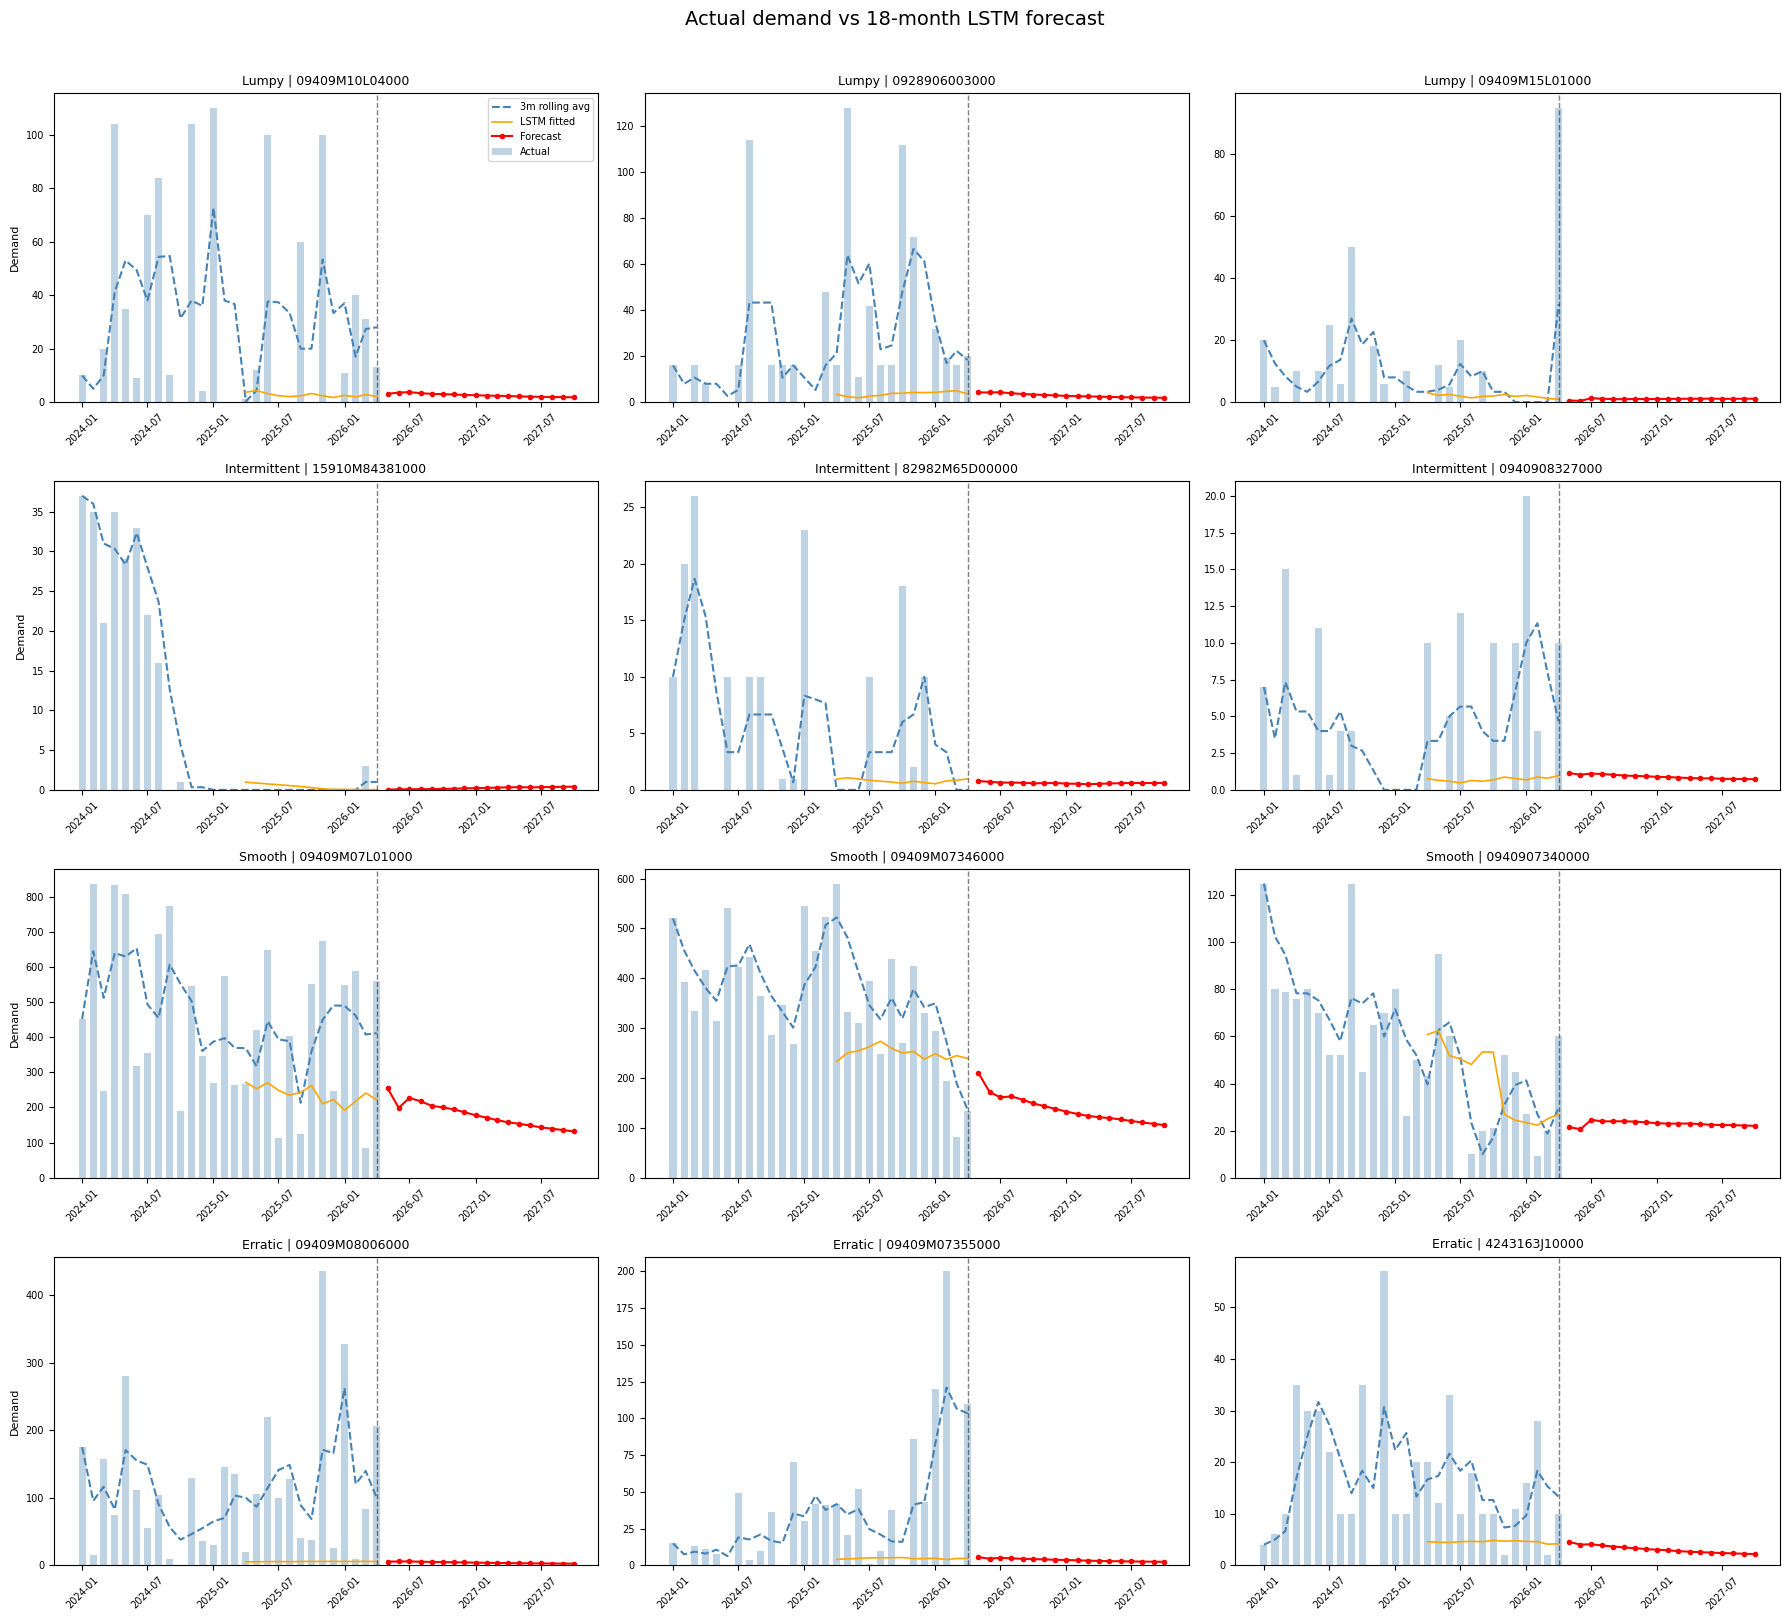

In [39]:
N_SKUS_PER_TYPE = 3
plot_types = [dt for dt in DEMAND_TYPES if dt in sales_collision["demand_type"].unique()]

fig, axes = plt.subplots(len(plot_types), N_SKUS_PER_TYPE, figsize=(18, len(plot_types) * 4))
fig.suptitle("Actual demand vs 18-month LSTM forecast", fontsize=14, y=1.01)

if len(plot_types) == 1:
    axes = np.array([axes])

for row_idx, dt in enumerate(plot_types):
    top_skus = (
        sales_collision[sales_collision["demand_type"] == dt]
        .groupby("sku_id")["demand"]
        .sum()
        .nlargest(N_SKUS_PER_TYPE)
        .index.tolist()
    )

    for col_idx, sku in enumerate(top_skus):
        ax = axes[row_idx][col_idx]

        actual = (
            sales_collision[sales_collision["sku_id"] == sku][["month", "demand"]]
            .sort_values("month")
            .copy()
        )
        actual["rolling_avg"] = actual["demand"].rolling(3, min_periods=1).mean()

        hist_fit = (
            insample_df[insample_df["sku_id"] == sku]
            .sort_values("month")
            if not insample_df.empty
            else pd.DataFrame(columns=["month", "lstm_insample"])
        )

        fc = (
            forecasts_18m[forecasts_18m["sku_id"] == sku][["month", "forecast"]]
            .sort_values("month")
        )

        ax.bar(actual["month"], actual["demand"], color="steelblue", alpha=0.35, label="Actual", width=20)
        ax.plot(actual["month"], actual["rolling_avg"], color="steelblue", linestyle="--", linewidth=1.5, label="3m rolling avg")
        if not hist_fit.empty:
            ax.plot(hist_fit["month"], hist_fit["lstm_insample"], color="orange", linewidth=1.2, label="LSTM fitted")
        ax.plot(fc["month"], fc["forecast"], color="red", marker="o", markersize=3, linewidth=1.5, label="Forecast")

        ax.axvline(x=last_month, color="black", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_title(f"{dt} | {sku}", fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        if col_idx == 0:
            ax.set_ylabel("Demand", fontsize=8)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("lstm_forecast_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save outputs



In [40]:
forecasts_18m.to_csv("lstm_forecasts_18m.csv", index=False)
summary_df.to_csv("lstm_wmape_summary.csv", index=False)
backtest_metrics.to_csv("lstm_backtest_metrics.csv", index=False)
backtest_predictions.to_csv("lstm_backtest_predictions.csv", index=False)
sku_wmape.to_csv("lstm_sku_wmape.csv", index=False)

print("Saved outputs:")
print("- lstm_forecasts_18m.csv")
print("- lstm_forecast_sample.png")
print("- lstm_wmape_summary.csv")
print("- lstm_backtest_metrics.csv")
print("- lstm_backtest_predictions.csv")
print("- lstm_sku_wmape.csv")

Saved outputs:
- lstm_forecasts_18m.csv
- lstm_forecast_sample.png
- lstm_wmape_summary.csv
- lstm_backtest_metrics.csv
- lstm_backtest_predictions.csv
- lstm_sku_wmape.csv


## 11. Results summary text

Use the printed output below in the group report/presentation.



In [41]:
print("=" * 70)
print("LSTM Demand Forecasting - Results Summary")
print("=" * 70)

print("\nScope")
print(f"  Total collision SKUs     : {sales_collision['sku_id'].nunique():,}")
print(f"  Total rows               : {sales_collision.shape[0]:,}")
print(f"  Forecast horizon         : {N_FORECAST} months")
print(f"  Forecast lag             : {FORECAST_LAG} months")
print(f"  LSTM sequence window     : {WINDOW} months")

print("\nDemand type distribution")
dt_counts = sales_collision.groupby("sku_id")["demand_type"].first().value_counts()
for dt, n in dt_counts.items():
    print(f"  {dt:<25}: {n:,} SKUs")

print("\nWMAPE comparison: baseline vs LSTM")
print(f"  {'Demand type':<15} {'Baseline':>10} {'LSTM':>10} {'Improvement':>12}")
print(f"  {'-' * 52}")
for _, row in summary_df.iterrows():
    print(
        f"  {row['demand_type']:<15} "
        f"{row['baseline_wmape']:>10.4f} "
        f"{row['lstm_wmape']:>10.4f} "
        f"{row['improvement_pct']:>+11.1f}%"
    )

if not improved.empty:
    total_in_top20 = sku_meta[sku_meta["is_top20pct"] == 1]["sku_id"].nunique()
    total_in_top5 = sku_meta[sku_meta["is_top5pct"] == 1]["sku_id"].nunique()
    imp_in_top20 = improved[improved["is_top20pct"] == 1]["sku_id"].nunique()
    imp_in_top5 = improved[improved["is_top5pct"] == 1]["sku_id"].nunique()
    print("\nSKU-level improvement (>10% WMAPE reduction)")
    print(f"  Improved SKUs            : {len(improved):,}")
    print(f"  Improved in top 20% SKUs : {imp_in_top20:,} of {total_in_top20:,} ({imp_in_top20 / total_in_top20 * 100:.1f}%)")
    print(f"  Improved in top 5% SKUs  : {imp_in_top5:,} of {total_in_top5:,} ({imp_in_top5 / total_in_top5 * 100:.1f}%)")

print("\nInterpretation guide")
print("  - Smooth SKUs are expected to be the most suitable category for LSTM because they have frequent demand.")
print("  - Intermittent and Lumpy SKUs often require fallback logic because many series have too little sequential signal.")
print("  - Erratic SKUs may overfit spikes; compare their LSTM WMAPE carefully against the rolling-average baseline.")
print("  - No demand observed SKUs are assigned a zero forecast rather than modelled.")
print("=" * 70)

LSTM Demand Forecasting - Results Summary

Scope
  Total collision SKUs     : 8,097
  Total rows               : 180,422
  Forecast horizon         : 18 months
  Forecast lag             : 3 months
  LSTM sequence window     : 12 months

Demand type distribution
  Intermittent             : 6,593 SKUs
  Smooth                   : 972 SKUs
  Lumpy                    : 381 SKUs
  Erratic                  : 124 SKUs
  No demand observed       : 27 SKUs

WMAPE comparison: baseline vs LSTM
  Demand type       Baseline       LSTM  Improvement
  ----------------------------------------------------
  Lumpy               1.3597     1.0304       +24.2%
  Intermittent        1.4436     1.1388       +21.1%
  Smooth              0.4663     0.5030        -7.9%
  Erratic             0.7635     0.7417        +2.9%

SKU-level improvement (>10% WMAPE reduction)
  Improved SKUs            : 2,204
  Improved in top 20% SKUs : 567 of 1,325 (42.8%)
  Improved in top 5% SKUs  : 105 of 325 (32.3%)

Interpreta

In [42]:
import glob

print("Current folder:", os.getcwd())
print("LSTM files found:")
for f in glob.glob("/content/lstm*"):
    print(f)

Current folder: /content
LSTM files found:
/content/lstm_backtest_predictions.csv
/content/lstm_backtest_metrics.csv
/content/lstm_wmape_summary.csv
/content/lstm_wmape_lt70_analysis.csv
/content/lstm_forecast_sample.png
/content/lstm_forecasts_18m.csv
/content/lstm_sku_wmape.csv


In [43]:
from google.colab import files

for f in glob.glob("/content/lstm*"):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>